## Install Libraries

In [ ]:
!pip install yfinance pandas-ta --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, which is not installed.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 2 — Download Your 4 Assets (5 minutes)

In [ ]:


# Define our 4 assets
tickers = {
    "NIFTY50"  : "^NSEI",
    "Reliance" : "RELIANCE.NS",
    "TCS"      : "TCS.NS",
    "Bitcoin"  : "BTC-USD"
}

# Download 5 years of daily data
raw_data = {}

for name, ticker in tickers.items():
    df = yf.download(ticker, start="2019-01-01", end="2024-12-31", progress=False)
    raw_data[name] = df
    print(f"{name}: {len(df)} rows downloaded ✓")

NIFTY50: 1477 rows downloaded ✓
Reliance: 1480 rows downloaded ✓
TCS: 1480 rows downloaded ✓
Bitcoin: 2191 rows downloaded ✓


## Step 3 — Look at Your Data

In [ ]:
# Look at Reliance data
print("Shape:", raw_data["Reliance"].shape)
print("\nFirst 5 rows:")
raw_data["Reliance"].head()

Shape: (1480, 5)

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2019-01-01,498.490601,501.292148,493.643566,500.380542,9746670
2019-01-02,491.998260,501.158754,489.596947,495.600186,15628818
2019-01-03,485.928314,495.644647,484.749906,492.487392,16288287
2019-01-04,488.551910,491.131092,480.747723,487.996071,18516544
2019-01-07,491.264465,497.356638,489.596889,492.265005,12060290


## Step 4 — Your First Plot

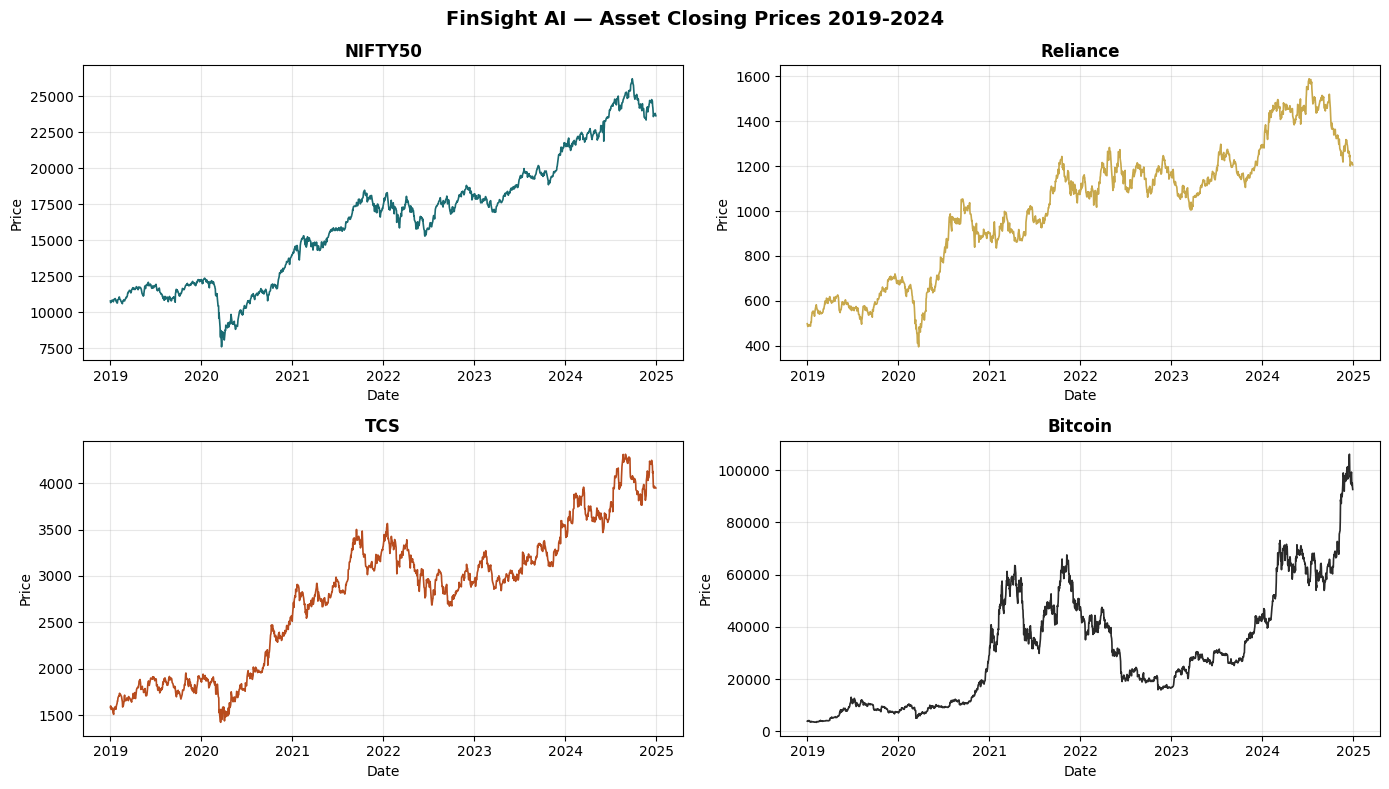

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("FinSight AI — Asset Closing Prices 2019-2024",
             fontsize=14, fontweight='bold')

assets = list(raw_data.keys())
colors = ['#1a6b72', '#c8a84b', '#b84c1e', '#2a2a2a']

for idx, (name, color) in enumerate(zip(assets, colors)):
    row, col = idx // 2, idx % 2
    axes[row, col].plot(raw_data[name].index,
                        raw_data[name]['Close'],
                        color=color, linewidth=1.2)
    axes[row, col].set_title(name, fontweight='bold')
    axes[row, col].set_xlabel("Date")
    axes[row, col].set_ylabel("Price")
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## *Step 5 — Compute Log Returns*

In [ ]:
# Compute log returns for all assets
returns_data = {}

for name, df in raw_data.items():
    returns = pd.DataFrame()
    returns['Close'] = df['Close']
    returns['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    returns = returns.dropna()
    returns_data[name] = returns
    print(f"{name} — Mean daily return: {returns['Log_Return'].mean():.4f} | "
          f"Std: {returns['Log_Return'].std():.4f}")

NIFTY50 — Mean daily return: 0.0005 | Std: 0.0117
Reliance — Mean daily return: 0.0006 | Std: 0.0184
TCS — Mean daily return: 0.0006 | Std: 0.0152
Bitcoin — Mean daily return: 0.0015 | Std: 0.0343


# Now plot the difference between price and returns — this is the visual proof of why returns matter:

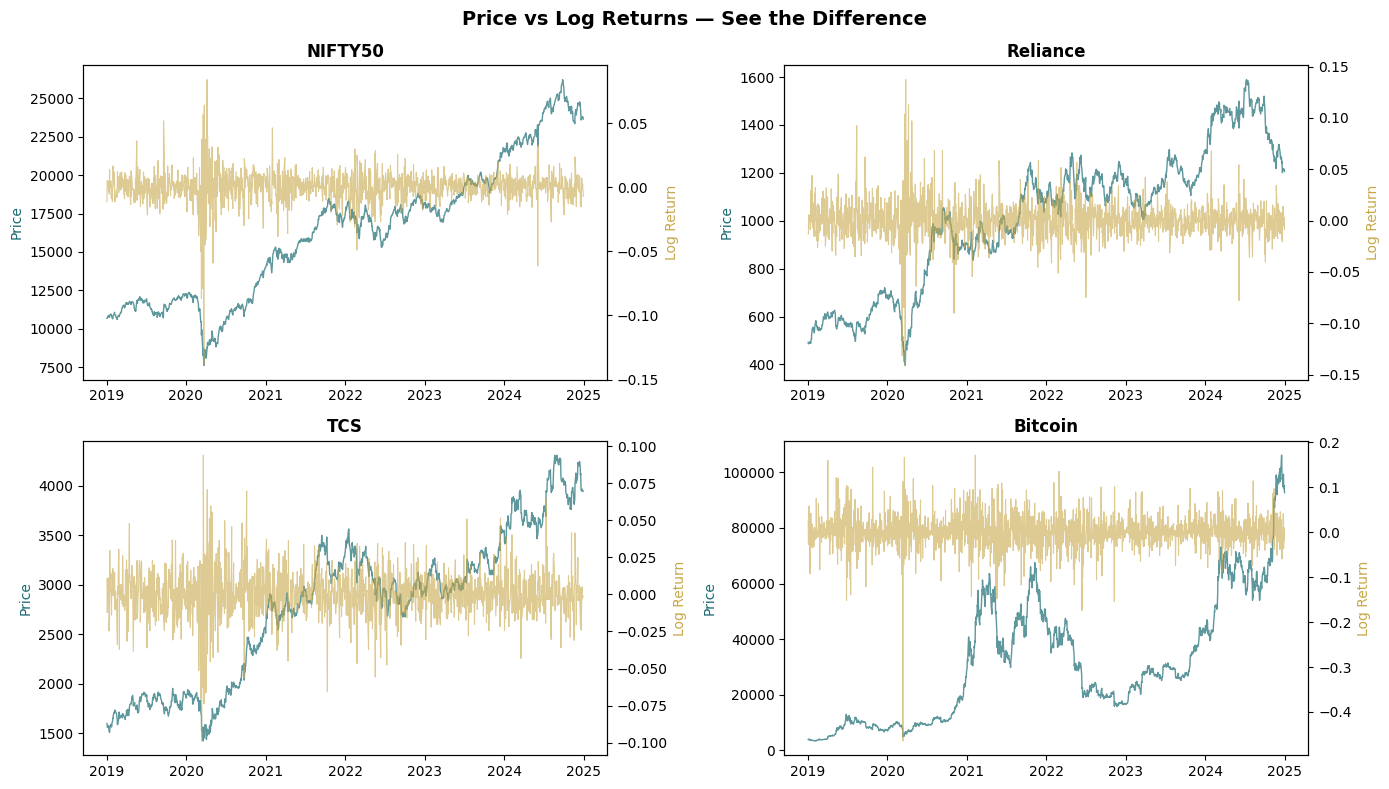


KEY INSIGHT: Price drifts upward (non-stationary).
Log returns fluctuate around 0 (stationary).
Neural networks learn from returns, NOT raw prices.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Price vs Log Returns — See the Difference",
             fontsize=14, fontweight='bold')

for idx, name in enumerate(assets):
    row, col = idx // 2, idx % 2
    ax1 = axes[row, col]
    ax2 = ax1.twinx()

    ax1.plot(returns_data[name].index,
             returns_data[name]['Close'],
             color='#1a6b72', linewidth=1, alpha=0.7, label='Price')
    ax2.plot(returns_data[name].index,
             returns_data[name]['Log_Return'],
             color='#c8a84b', linewidth=0.8, alpha=0.6, label='Log Return')

    ax1.set_title(name, fontweight='bold')
    ax1.set_ylabel("Price", color='#1a6b72')
    ax2.set_ylabel("Log Return", color='#c8a84b')

plt.tight_layout()
plt.show()

print("\nKEY INSIGHT: Price drifts upward (non-stationary).")
print("Log returns fluctuate around 0 (stationary).")
print("Neural networks learn from returns, NOT raw prices.")

## Step *6* — Stationarity Test

In [ ]:
from statsmodels.tsa.stattools import adfuller

print("=" * 55)
print("AUGMENTED DICKEY-FULLER TEST RESULTS")
print("Null hypothesis: Series is NON-stationary")
print("If p-value < 0.05 → Series IS stationary")
print("=" * 55)

for name in assets:
    price_series = returns_data[name]['Close'].dropna()
    return_series = returns_data[name]['Log_Return'].dropna()

    _, p_price, _, _, _, _ = adfuller(price_series)
    _, p_return, _, _, _, _ = adfuller(return_series)

    price_verdict  = "✓ STATIONARY" if p_price  < 0.05 else "✗ NON-STATIONARY"
    return_verdict = "✓ STATIONARY" if p_return < 0.05 else "✗ NON-STATIONARY"

    print(f"\n{name}:")
    print(f"  Raw Price  → p={p_price:.4f}  → {price_verdict}")
    print(f"  Log Return → p={p_return:.4f} → {return_verdict}")

AUGMENTED DICKEY-FULLER TEST RESULTS
Null hypothesis: Series is NON-stationary
If p-value < 0.05 → Series IS stationary

NIFTY50:
  Raw Price  → p=0.9186  → ✗ NON-STATIONARY
  Log Return → p=0.0000 → ✓ STATIONARY

Reliance:
  Raw Price  → p=0.3950  → ✗ NON-STATIONARY
  Log Return → p=0.0000 → ✓ STATIONARY

TCS:
  Raw Price  → p=0.7284  → ✗ NON-STATIONARY
  Log Return → p=0.0000 → ✓ STATIONARY

Bitcoin:
  Raw Price  → p=0.8798  → ✗ NON-STATIONARY
  Log Return → p=0.0000 → ✓ STATIONARY


## Indicators

In [11]:
import pandas_ta as ta

featured_data = {}

for name, df in raw_data.items():
    feat = pd.DataFrame(index=df.index)
    feat['Close']       = df['Close'].squeeze()
    feat['Log_Return']  = np.log(feat['Close'] / feat['Close'].shift(1))
    feat['Volume_Ratio'] = df['Volume'].squeeze() / df['Volume'].squeeze().rolling(20).mean()

    # RSI — safe
    feat['RSI'] = ta.rsi(feat['Close'], length=14)

    # MACD — safe extraction
    macd_df = ta.macd(feat['Close'])
    if macd_df is not None:
        feat['MACD'] = macd_df.iloc[:, 0]

    # Bollinger Bands — safe extraction
    bb_df = ta.bbands(feat['Close'], length=20)
    if bb_df is not None:
        feat['BB_upper'] = bb_df.iloc[:, 2]
        feat['BB_lower'] = bb_df.iloc[:, 0]

    feat = feat.dropna()
    featured_data[name] = feat
    print(f"{name}: {feat.shape[1]} features, {len(feat)} rows ✓")

NIFTY50: 7 features, 1452 rows ✓
Reliance: 7 features, 1455 rows ✓
TCS: 7 features, 1455 rows ✓
Bitcoin: 7 features, 2166 rows ✓


## ARIMA baseline

In [12]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ARIMA baseline on Reliance log returns
series = featured_data['Reliance']['Log_Return'].dropna()
train  = series[:-30]
test   = series[-30:]

model      = ARIMA(train, order=(2,0,2))
arima_fit  = model.fit()
preds      = arima_fit.forecast(steps=30)

mae  = mean_absolute_error(test, preds)
rmse = np.sqrt(mean_squared_error(test, preds))

print("=" * 40)
print("ARIMA BASELINE — RELIANCE LOG RETURNS")
print("=" * 40)
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print()
print("⚡ Beat this with LSTM tomorrow.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA BASELINE — RELIANCE LOG RETURNS
MAE  : 0.011502
RMSE : 0.013421

⚡ Beat this with LSTM tomorrow.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
